# Outlier Analysis Visualization
Load `outlier_results.h5` produced by notebook 3 and plot grid-point statistics
as a function of `amp_prefactor` and `charge_gate`.

In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from scqat.parsers.xarray_h5_parser import load_xarray_h5

## 1. Configuration

In [22]:
ROOT_FOLDER = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q2\ng01_ref0165_test04\three_step_AR"

OUTLIER_RESULTS_PATH = os.path.join(ROOT_FOLDER, "outlier_results.h5")
POST_SELECTED_PATH = os.path.join(ROOT_FOLDER, "ro_charge_power_post_selected.h5")

FIGURE_SAVE_PATH = os.path.join(ROOT_FOLDER, "figures")
os.makedirs(FIGURE_SAVE_PATH, exist_ok=True)

AMP_PREFACTOR_MAX_N = 1.0  # All amp_prefactor values are multiplied by this factor
# photon_convert_factor = 542  # Set to None to use raw amp_prefactor Q1
photon_convert_factor = 923  # Set to None to use raw amp_prefactor Q2

# voltage_to_charge_factor = 0.5376  # Adjust this factor based on your system's calibration Q1
voltage_to_charge_factor = 0.59  # Adjust this factor based on your system's calibration Q2

## 2. Load Dataset

In [23]:
result_ds = load_xarray_h5(OUTLIER_RESULTS_PATH)
result_ds = result_ds.assign_coords(
    amp_prefactor=result_ds.coords['amp_prefactor'] * AMP_PREFACTOR_MAX_N
)
if photon_convert_factor is not None:
    result_ds = result_ds.assign_coords(
        amp_prefactor=result_ds.coords['amp_prefactor']**2 * photon_convert_factor
    ).rename({'amp_prefactor': 'photon_number'})
    y_dim = 'photon_number'
else:
    y_dim = 'amp_prefactor'

if voltage_to_charge_factor is not None:
    result_ds = result_ds.assign_coords(
        charge_gate=result_ds.coords['charge_gate'] * voltage_to_charge_factor
    ).rename({'charge_gate': 'ng'})
    x_dim = 'ng'
else:
    x_dim = 'charge_gate'
result_ds

<xarray.Dataset> Size: 126kB
Dimensions:                   (prepared_state: 2, photon_number: 20, ng: 49)
Coordinates:
  * prepared_state            (prepared_state) int32 8B 0 1
  * photon_number             (photon_number) float64 160B 0.0 ... 3.332e+03
  * ng                        (ng) float64 392B 0.0 0.0059 ... 0.2773 0.2832
Data variables:
    outlier_probability_set3  (prepared_state, photon_number, ng) float64 16kB ...
    I_mean_set3               (prepared_state, photon_number, ng) float64 16kB ...
    Q_mean_set3               (prepared_state, photon_number, ng) float64 16kB ...
    std_set3                  (prepared_state, photon_number, ng) float64 16kB ...
    outlier_probability_set2  (prepared_state, photon_number, ng) float64 16kB ...
    I_mean_set2               (prepared_state, photon_number, ng) float64 16kB ...
    Q_mean_set2               (prepared_state, photon_number, ng) float64 16kB ...
    std_set2                  (prepared_state, photon_number, ng) float64 16kB ...
Attributes:
    abscos_frequency_fixed:  0.59
    mean:                    [-0.0015745  -0.00161383]
    std:                     0.000553464982804952
    outlier_sigma:           3

In [24]:
# Save lite plot dataset in compact format for future plotting
plot_lite = (
    result_ds[['outlier_probability_set2', 'outlier_probability_set3']]
    .rename({
        'outlier_probability_set2': 'M2',
        'outlier_probability_set3': 'M3',
        'prepared_state': 'init_state',
    })
    .transpose(x_dim, y_dim, 'init_state')
)
plot_lite_save_path = os.path.join(ROOT_FOLDER, "outlier_plot_exp.h5")
plot_lite.to_netcdf(plot_lite_save_path, engine='netcdf4')
print(f"Saved lite plot dataset to {plot_lite_save_path}")
print(plot_lite)


Saved lite plot dataset to D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q2\ng01_ref0165_test04\three_step_AR\outlier_plot_exp.h5
<xarray.Dataset> Size: 32kB
Dimensions:        (init_state: 2, photon_number: 20, ng: 49)
Coordinates:
  * init_state     (init_state) int32 8B 0 1
  * photon_number  (photon_number) float64 160B 0.0 9.23 ... 2.991e+03 3.332e+03
  * ng             (ng) float64 392B 0.0 0.0059 0.0118 ... 0.2714 0.2773 0.2832
Data variables:
    M2             (ng, photon_number, init_state) float64 16kB 0.01483 ... 0...
    M3             (ng, photon_number, init_state) float64 16kB 0.00659 ... 0...
Attributes:
    abscos_frequency_fixed:  0.59
    mean:                    [-0.0015745  -0.00161383]
    std:                     0.000553464982804952
    outlier_sigma:           3


## 3. Plot Grid-Point Statistics
For each prepared state, plot side-by-side comparisons of set_2 (left) vs set_3 (right).

Saved std_state_0.png


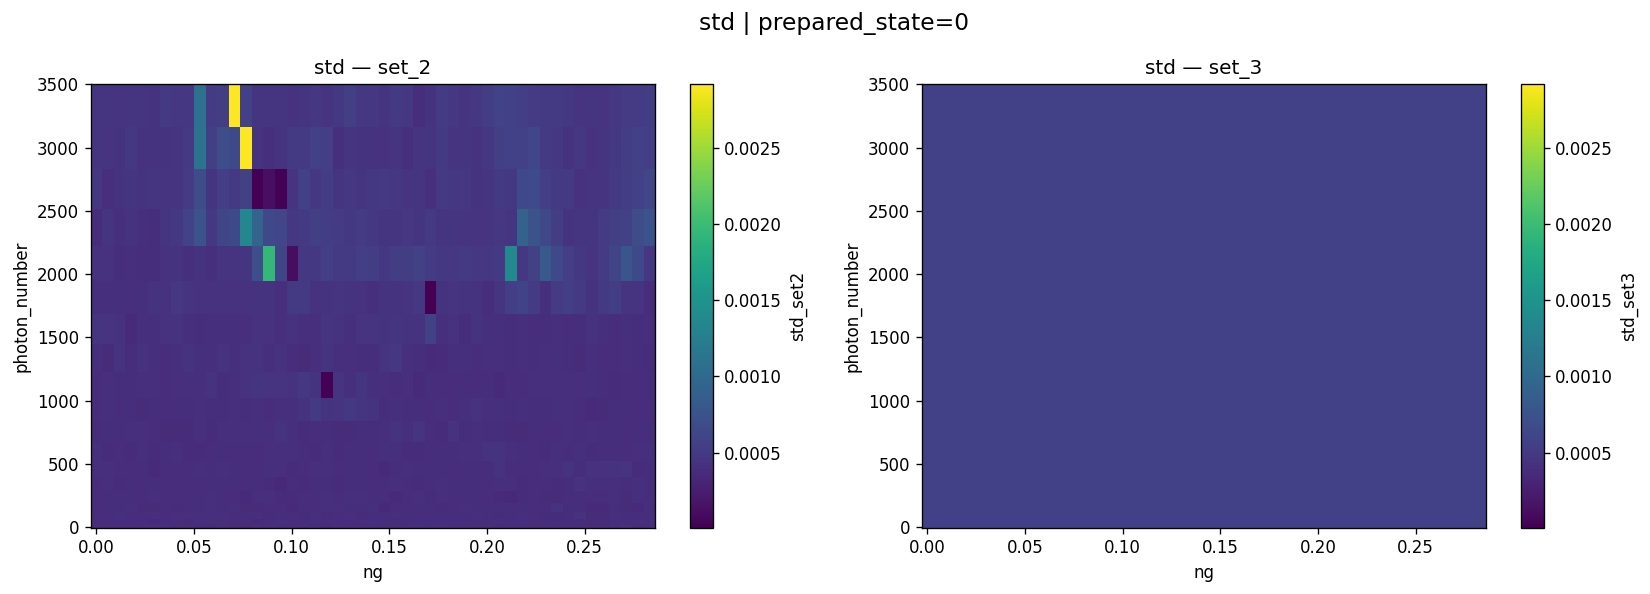

Saved I_mean_state_0.png


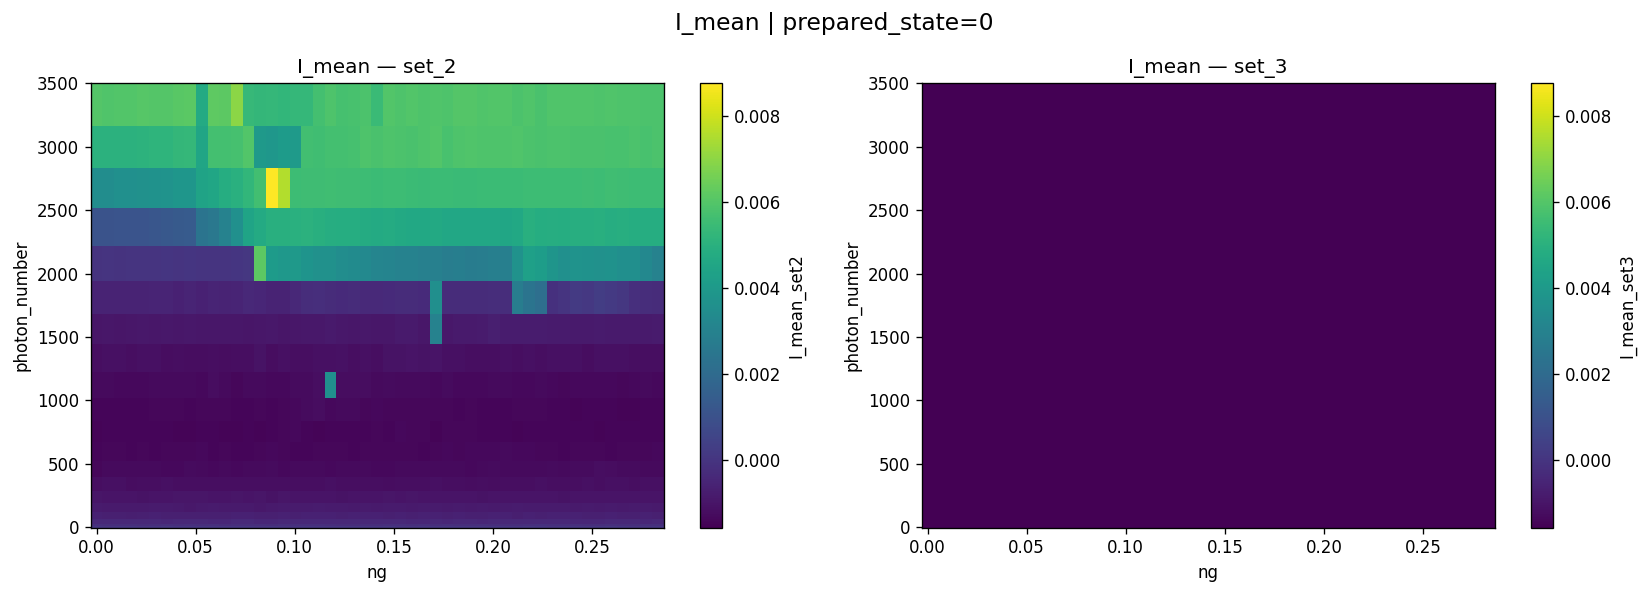

Saved Q_mean_state_0.png


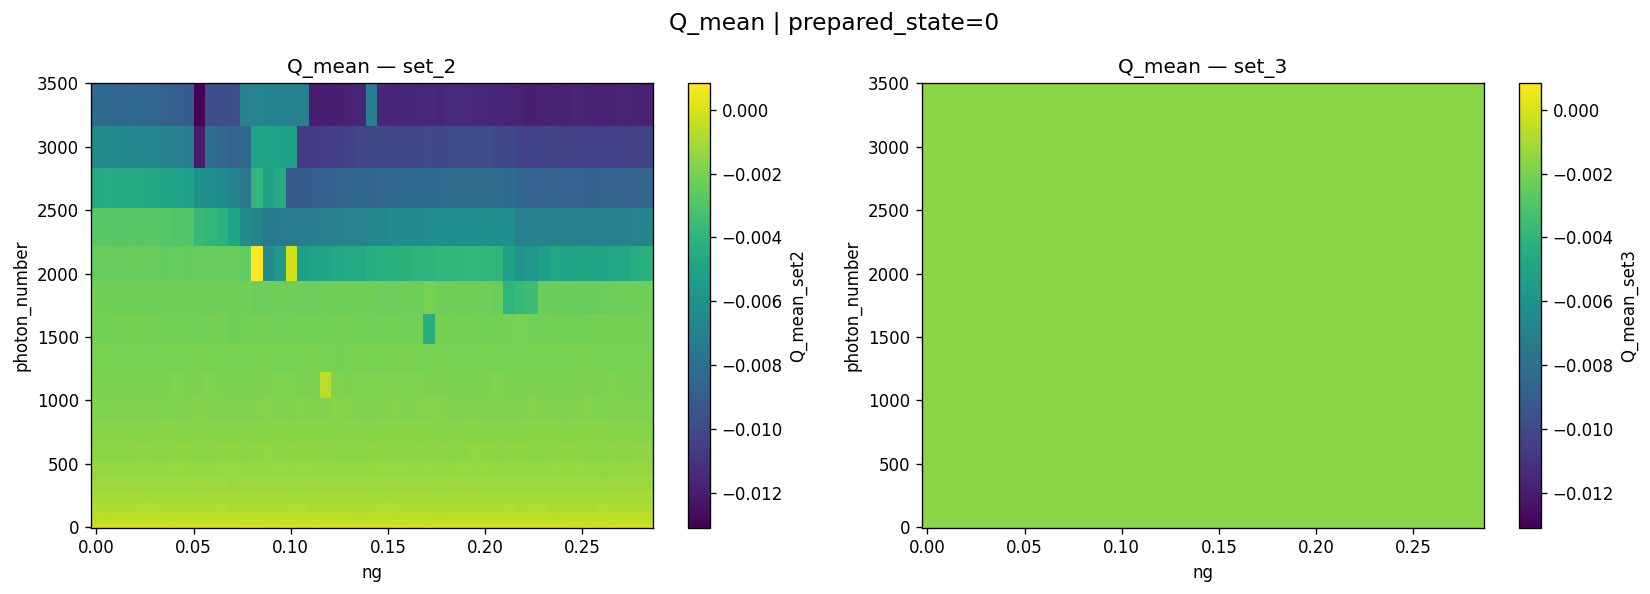

Saved outlier_probability_state_0.png


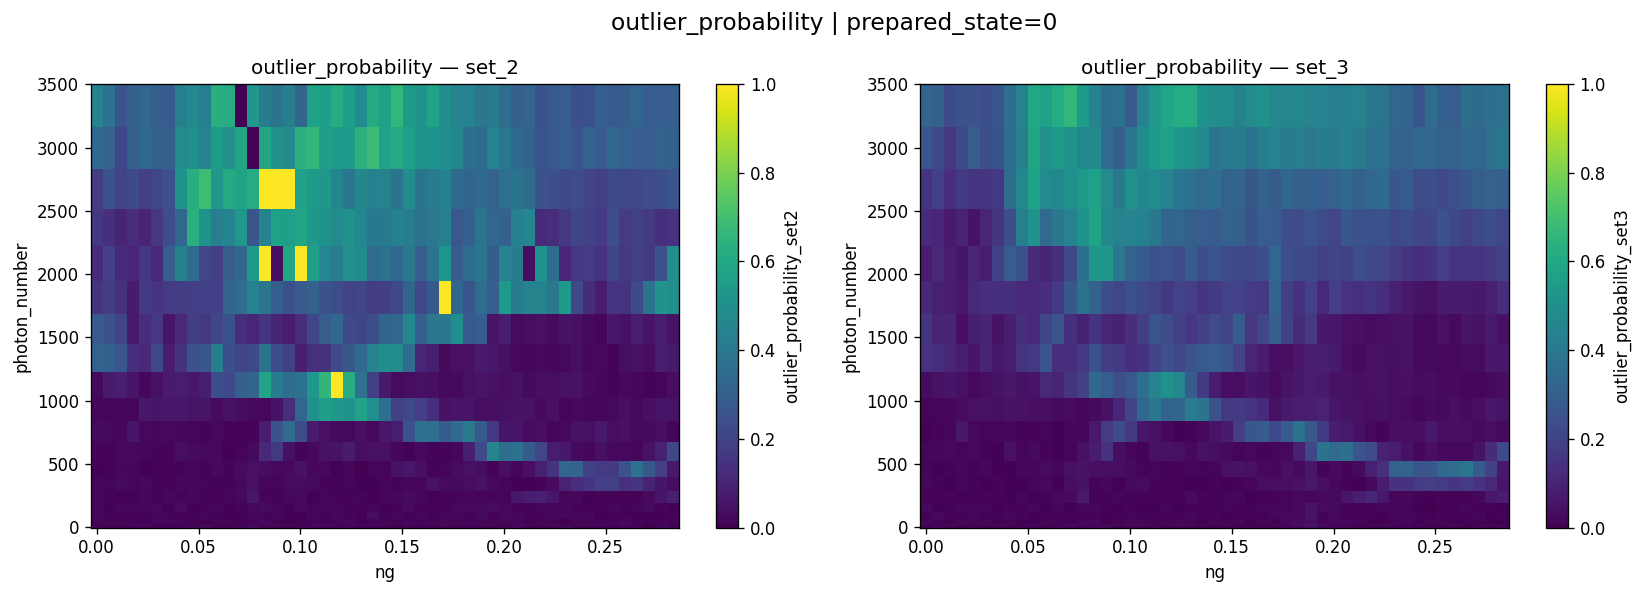

Saved std_state_1.png


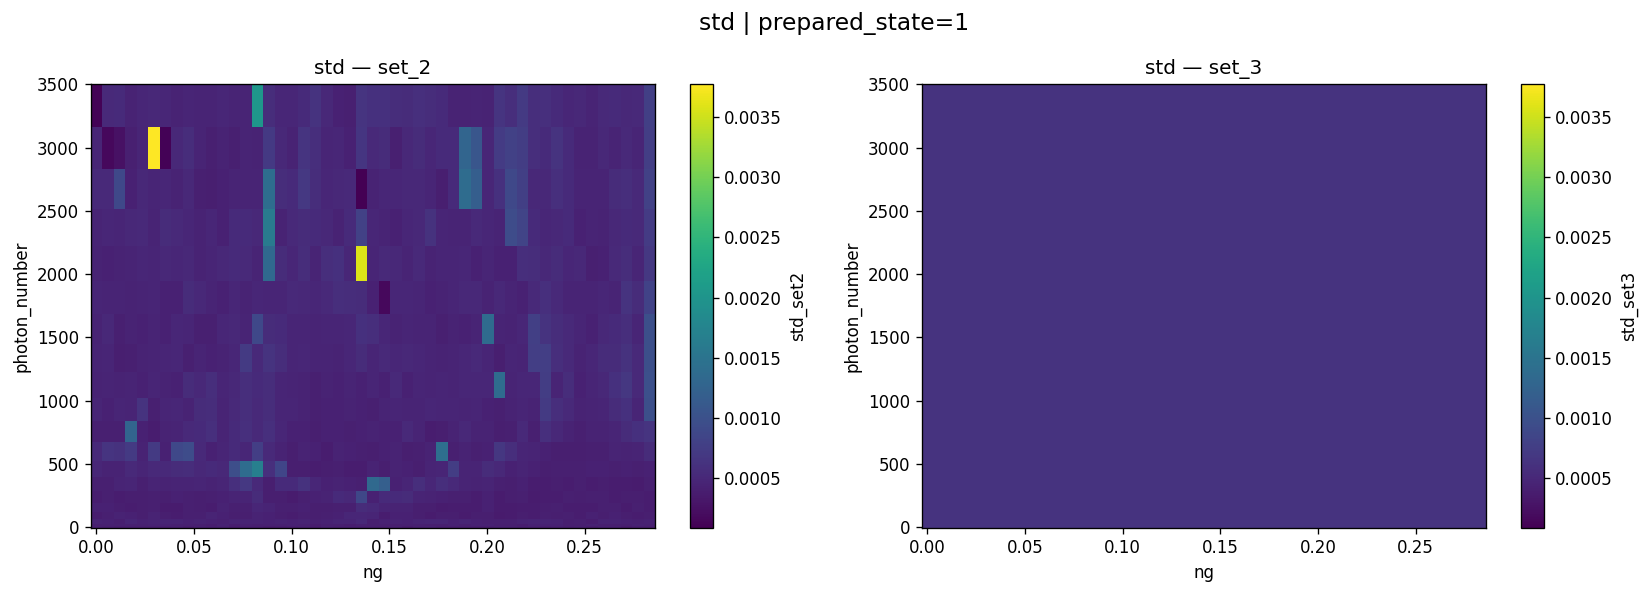

Saved I_mean_state_1.png


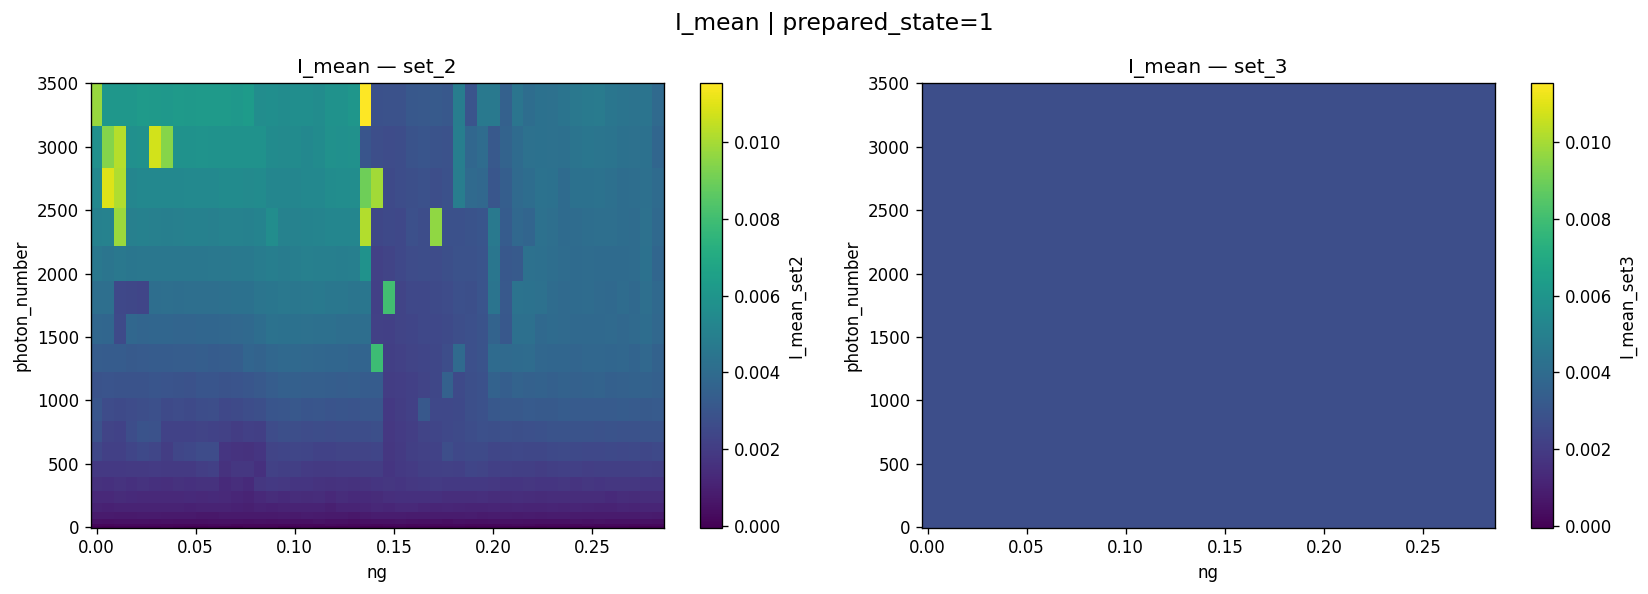

Saved Q_mean_state_1.png


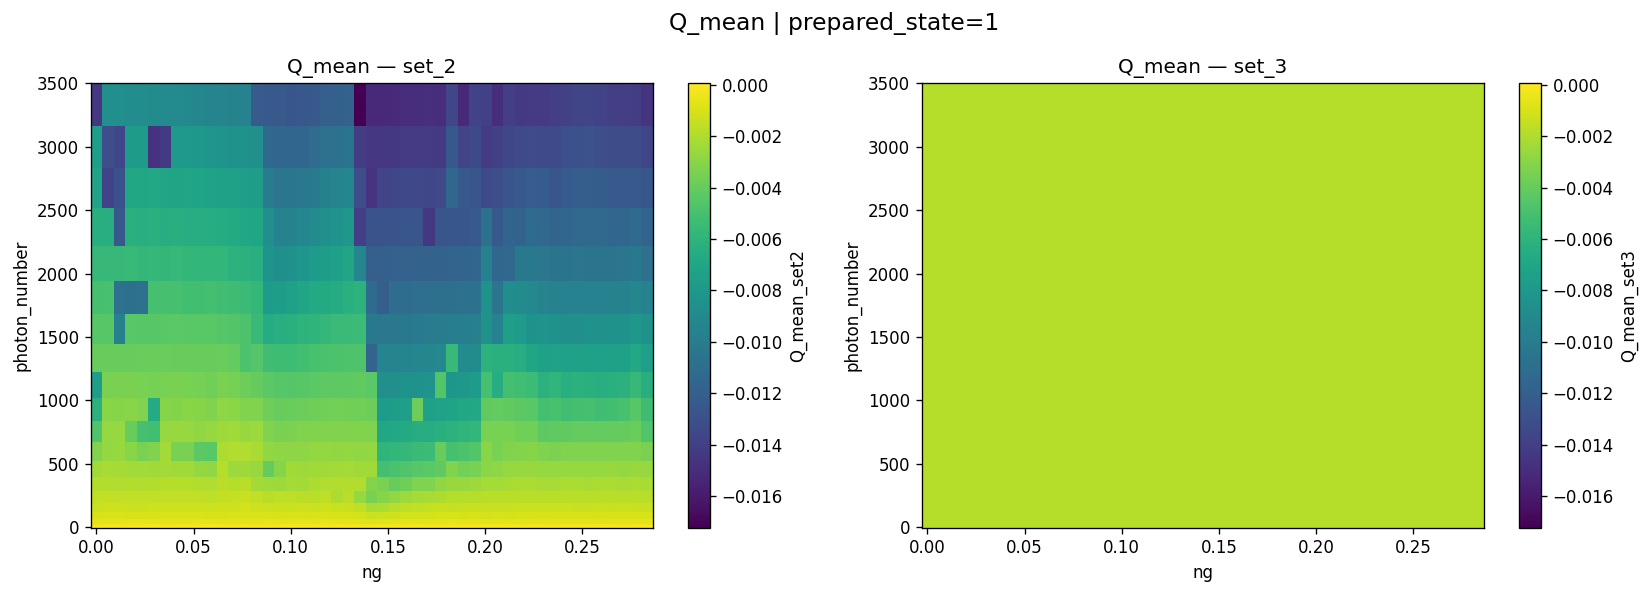

Saved outlier_probability_state_1.png


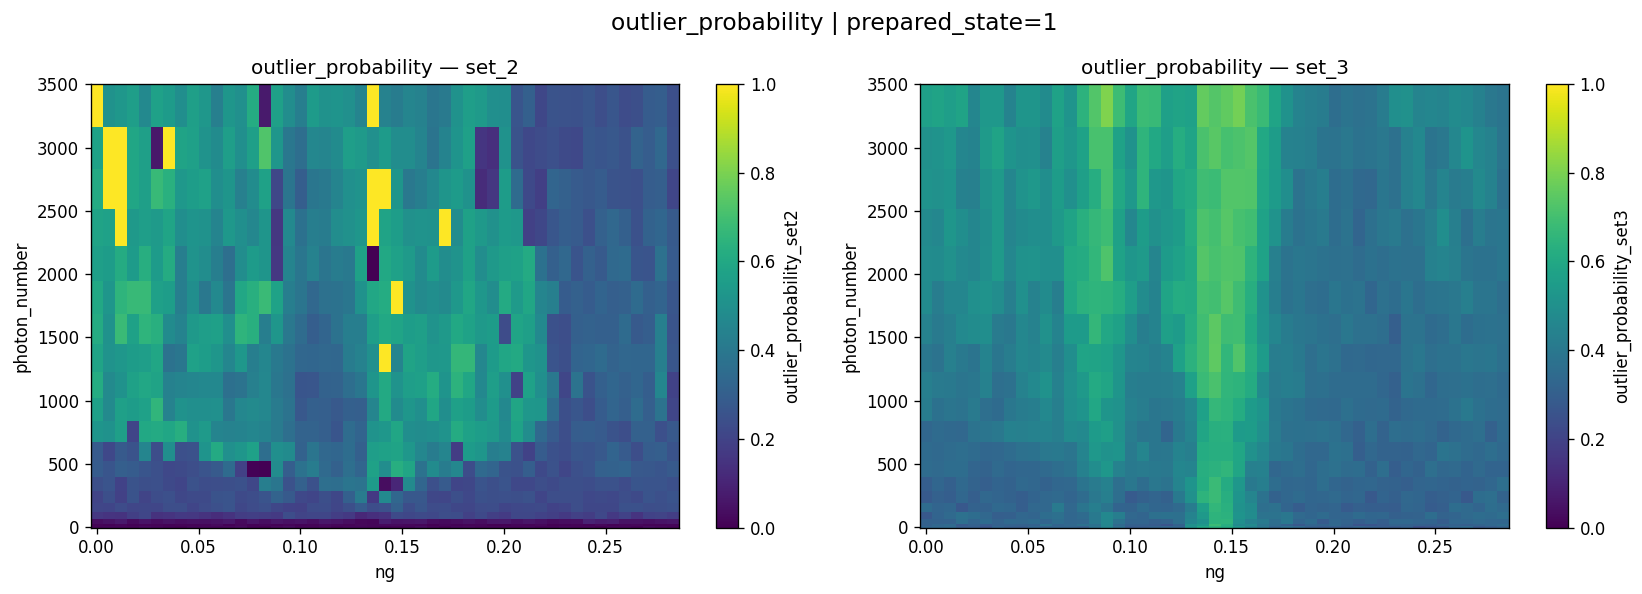

In [25]:
# Variable pairs to plot: (set2_var, set3_var, display_label)
var_pairs = [
    ('std_set2',                 'std_set3',                 'std'),
    ('I_mean_set2',              'I_mean_set3',              'I_mean'),
    ('Q_mean_set2',              'Q_mean_set3',              'Q_mean'),
    ('outlier_probability_set2', 'outlier_probability_set3', 'outlier_probability'),
]

prepared_states = result_ds.coords['prepared_state'].values

for state in prepared_states:
    for var2, var3, label in var_pairs:
        da2 = result_ds[var2].sel(prepared_state=state)
        da3 = result_ds[var3].sel(prepared_state=state)

        # Shared color range across set_2 and set_3
        import numpy as np
        vmin = float(np.nanmin([da2.min(), da3.min()]))
        vmax = float(np.nanmax([da2.max(), da3.max()]))

        fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

        da2.plot.pcolormesh(
            ax=axes[0], x=x_dim, y=y_dim,
            cmap='viridis', add_colorbar=True, vmin=vmin, vmax=vmax,
        )
        axes[0].set_title(f"{label} — set_2")

        da3.plot.pcolormesh(
            ax=axes[1], x=x_dim, y=y_dim,
            cmap='viridis', add_colorbar=True, vmin=vmin, vmax=vmax,
        )
        axes[1].set_title(f"{label} — set_3")

        fig.suptitle(f"{label} | prepared_state={int(state)}", fontsize=14)
        fig.tight_layout()

        fname = f"{label}_state_{int(state)}.png"
        fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
        print(f"Saved {fname}")
        plt.show()

Saved delta_I_set2.png


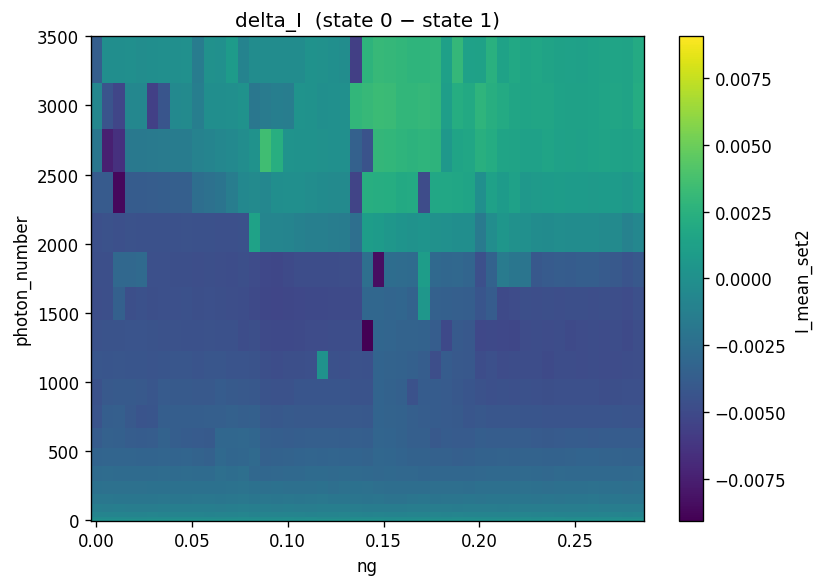

Saved delta_Q_set2.png


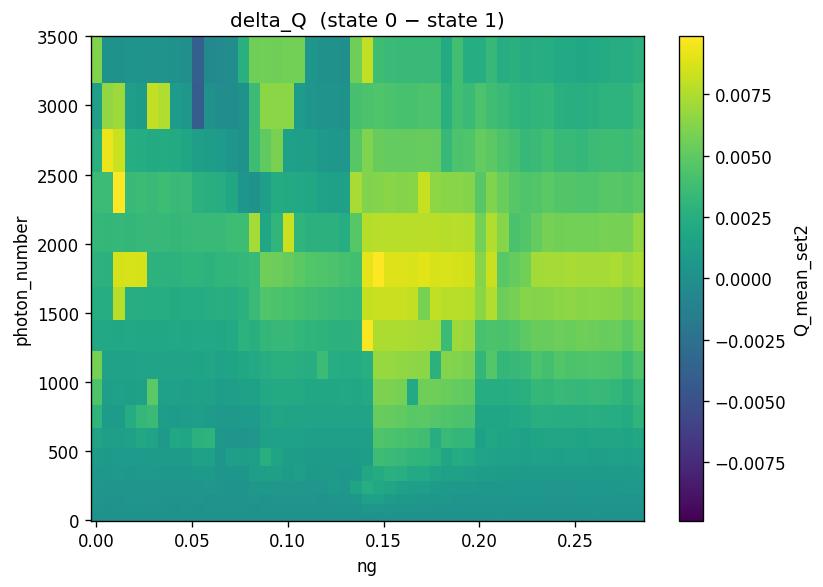

In [26]:
# Delta I, Delta Q, and IQ distance between prepared_state=0 and prepared_state=1
import numpy as np

delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
           - result_ds['I_mean_set2'].sel(prepared_state=1))
delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
           - result_ds['Q_mean_set2'].sel(prepared_state=1))
distance = np.sqrt(delta_I**2 + delta_Q**2)

for data, label in [(delta_I, 'delta_I'), (delta_Q, 'delta_Q')]:
    fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
    data.plot.pcolormesh(
        ax=ax, x=x_dim, y=y_dim,
        cmap='viridis', add_colorbar=True,
    )
    ax.set_title(f"{label}  (state 0 − state 1)")
    fig.tight_layout()

    fname = f"{label}_set2.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved IQ_distance_set2.png


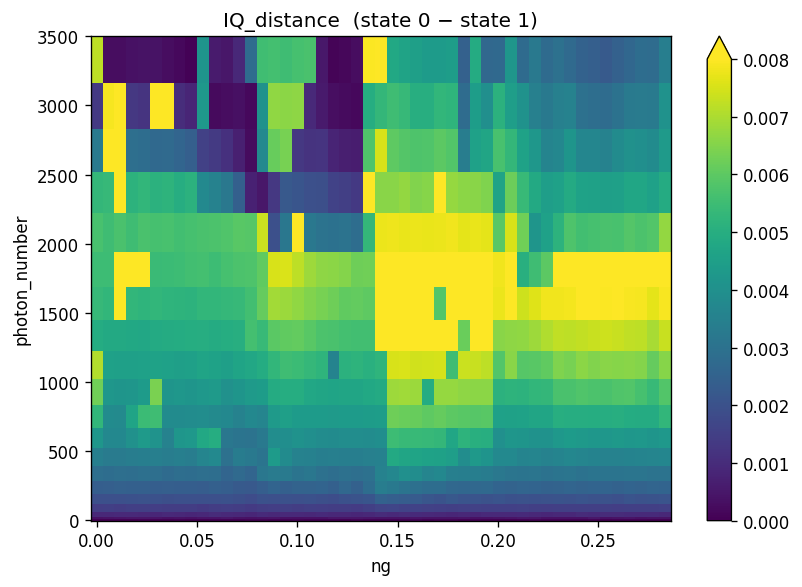

In [27]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
distance.plot.pcolormesh(
    ax=ax, x=x_dim, y=y_dim,
    cmap='viridis', add_colorbar=True, vmin=0, vmax=0.008,
)
ax.set_title("IQ_distance  (state 0 − state 1)")
fig.tight_layout()

fname = "IQ_distance_set2.png"
fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
print(f"Saved {fname}")
plt.show()

Saved IQ_distance_normalized_set2.png


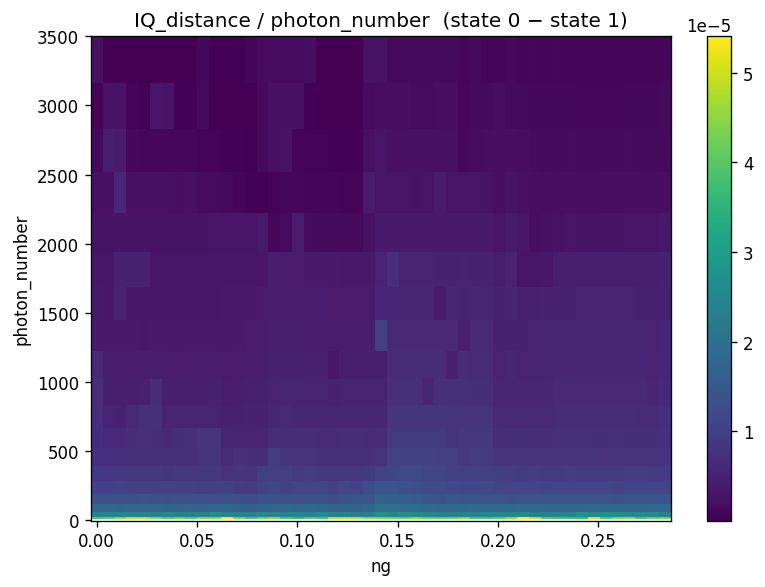

In [28]:
# Normalized distance: distance / y_dim (excluding y_dim == 0)
amp = distance.coords[y_dim]
norm_distance = distance.where(amp != 0) / amp.where(amp != 0)

fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
norm_distance.plot.pcolormesh(
    ax=ax, x=x_dim, y=y_dim,
    cmap='viridis', add_colorbar=True,
)
ax.set_title(f"IQ_distance / {y_dim}  (state 0 − state 1)")
fig.tight_layout()

fname = "IQ_distance_normalized_set2.png"
fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
print(f"Saved {fname}")
plt.show()

Saved mean_IQ_distance_vs_amp.png


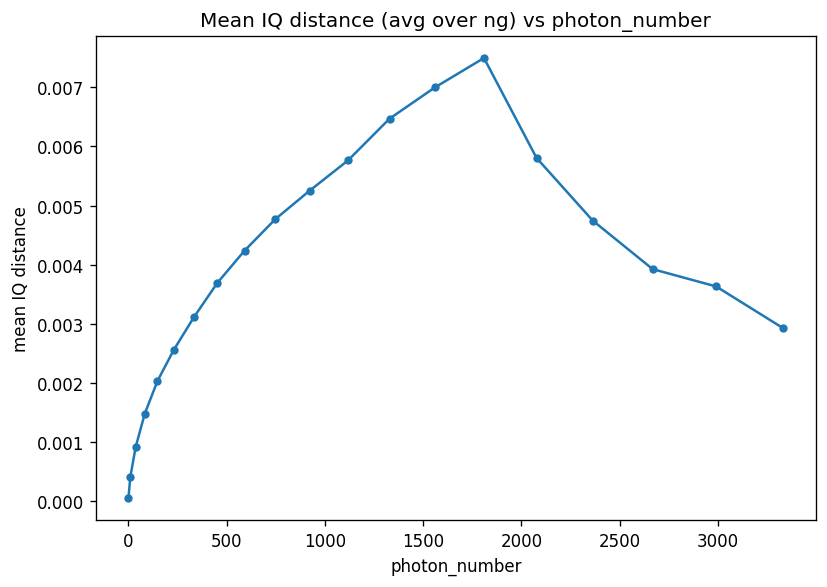

In [29]:
# Mean distance averaged along x_dim vs y_dim
mean_dist_vs_amp = distance.mean(dim=x_dim)

fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
mean_dist_vs_amp.plot.line(ax=ax, marker='o', markersize=4)
ax.set_xlabel(y_dim)
ax.set_ylabel('mean IQ distance')
ax.set_title(f'Mean IQ distance (avg over {x_dim}) vs {y_dim}')
fig.tight_layout()

fname = "mean_IQ_distance_vs_amp.png"
fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
print(f"Saved {fname}")
plt.show()

## 4. Single Grid-Point I/Q Scatter
Load `ro_charge_power_post_selected.h5` and plot per-shot I vs Q scatter at a user-chosen grid point,
with outliers highlighted.

In [30]:
import numpy as np

# --- User settings ---
SELECTED_STATE = 0       # prepared_state value
SELECTED_AMP   = 1.3     # amp_prefactor value (nearest match, before scaling)
SELECTED_CG    = 0.08    # charge_gate value   (nearest match)

ps_data = load_xarray_h5(POST_SELECTED_PATH)
ps_data = ps_data.assign_coords(
    amp_prefactor=ps_data.coords['amp_prefactor'] * AMP_PREFACTOR_MAX_N
)
if photon_convert_factor is not None:
    ps_data = ps_data.assign_coords(
        amp_prefactor=ps_data.coords['amp_prefactor']**2 * photon_convert_factor
    ).rename({'amp_prefactor': 'photon_number'})
if voltage_to_charge_factor is not None:
    ps_data = ps_data.assign_coords(
        charge_gate=ps_data.coords['charge_gate'] * voltage_to_charge_factor
    ).rename({'charge_gate': 'ng'})

# Select nearest grid point
sel_amp = SELECTED_AMP * AMP_PREFACTOR_MAX_N
if photon_convert_factor is not None:
    sel_amp = sel_amp**2 * photon_convert_factor
sel_cg = SELECTED_CG
if voltage_to_charge_factor is not None:
    sel_cg = sel_cg * voltage_to_charge_factor

cell = ps_data.sel(
    prepared_state=SELECTED_STATE,
    **{y_dim: sel_amp, x_dim: sel_cg},
    method='nearest',
)
actual_state = float(cell.coords['prepared_state'])
actual_amp   = float(cell.coords[y_dim])
actual_cg    = float(cell.coords[x_dim])
print(f"Selected grid point: prepared_state={actual_state}, "
      f"{y_dim}={actual_amp}, {x_dim}={actual_cg}")
cell

Selected grid point: prepared_state=0.0, photon_number=1559.8699999999994, ng=0.0472


<xarray.Dataset> Size: 35kB
Dimensions:         (shot_idx: 620)
Coordinates:
    prepared_state  int32 4B 0
    qubit           object 8B 'q1'
  * shot_idx        (shot_idx) int64 5kB 0 1 2 3 4 5 ... 614 615 616 617 618 619
    photon_number   float64 8B 1.56e+03
    ng              float64 8B 0.0472
Data variables:
    I1_1            (shot_idx) float64 5kB -0.001211 -0.001776 ... -0.0009145
    I1_2            (shot_idx) float64 5kB 0.002713 0.004016 ... -0.0001018
    I1_3            (shot_idx) float64 5kB -0.001061 -0.001834 ... -0.001514
    Q1_1            (shot_idx) float64 5kB -0.001714 -0.001303 ... -0.0008483
    Q1_2            (shot_idx) float64 5kB -0.005158 -0.007235 ... -0.001937
    Q1_3            (shot_idx) float64 5kB -0.002125 -0.0007488 ... -0.001361
    outlier_mask    (shot_idx) bool 620B False False False ... False False False
Attributes:
    abscos_frequency_fixed:  0.59
    mean:                    [-0.0015745  -0.00161383]
    std:                     0.000553464982804952

In [31]:
channel_pairs = [('I1_1', 'Q1_1'), ('I1_2', 'Q1_2'), ('I1_3', 'Q1_3')]
mask = cell['post_selection_mask'].values.astype(bool)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=120)
for ax, (i_var, q_var) in zip(axes, channel_pairs):
    I_vals = cell[i_var].values
    Q_vals = cell[q_var].values

    ax.scatter(I_vals[~mask], Q_vals[~mask], s=4, alpha=0.4, label='inlier', color='C0')
    ax.scatter(I_vals[mask],  Q_vals[mask],  s=8, alpha=0.7, label='post-selected', color='red', marker='x')
    ax.set_xlabel(i_var)
    ax.set_ylabel(q_var)
    ax.set_title(f"{i_var} vs {q_var}")
    ax.legend()
    ax.set_aspect('equal', adjustable='datalim')

fig.suptitle(f"I/Q scatter | state={actual_state}, amp={actual_amp}, cg={actual_cg}", fontsize=14)
fig.tight_layout()

fname = f"scatter_IQ_state{int(actual_state)}_amp{actual_amp}_cg{actual_cg}.png"
fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
print(f"Saved {fname}")
plt.show()


KeyError: "No variable named 'post_selection_mask'. Variables on the dataset include ['I1_1', 'I1_2', 'I1_3', 'Q1_1', 'Q1_2', ..., 'qubit', 'shot_idx', 'outlier_mask', 'photon_number', 'ng']"

Post-selected shots: 1033, Valid shots: 1033
Set-2 outliers: 260, Set-3 outliers: 157
Saved scatter_set23_outlier_state0_photon_number915.9799999999997_ng0.043008.png


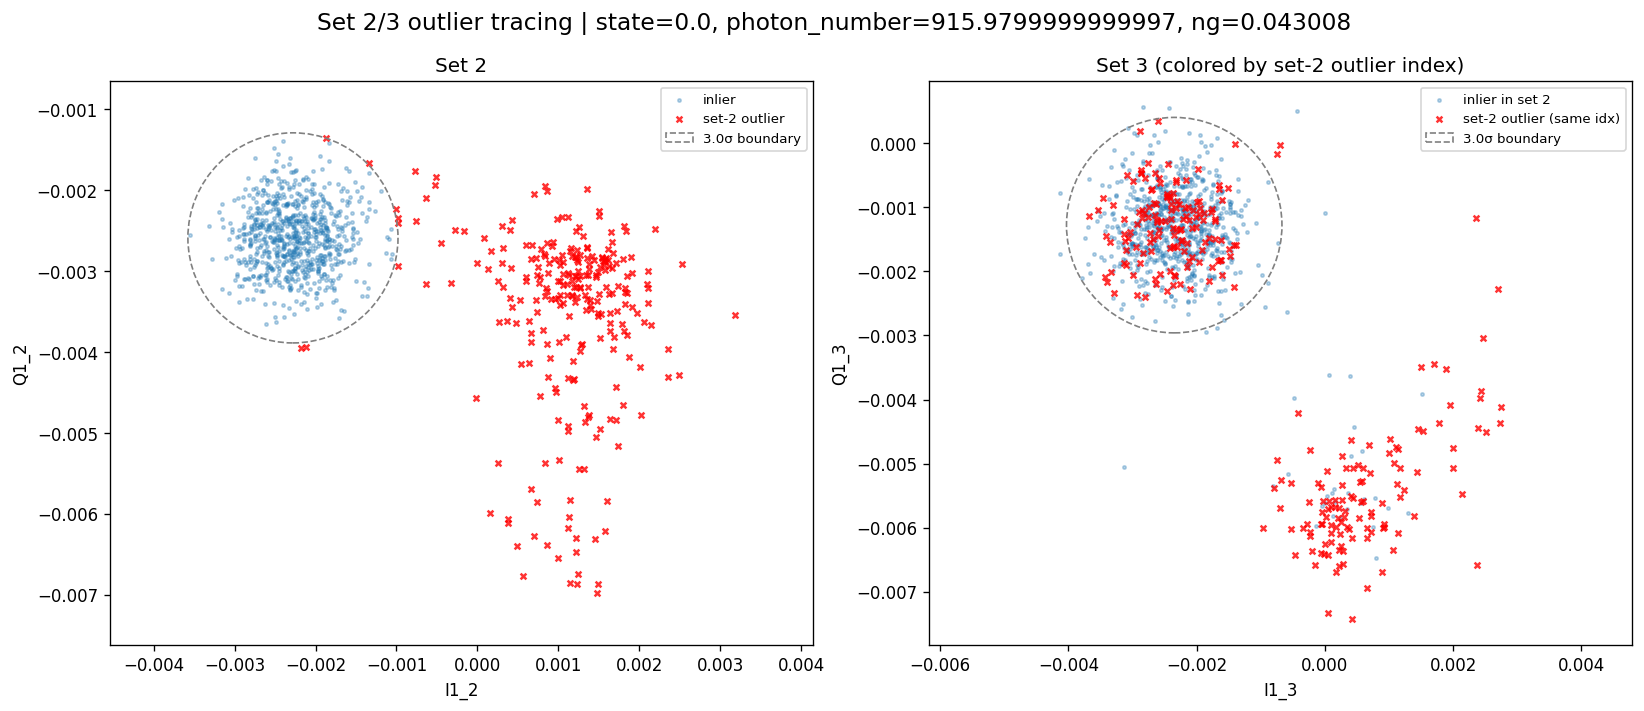

In [ ]:
# Set 2 / Set 3 scatter: highlight set-2 outliers and trace them in set 3
import numpy as np

ps_mask = cell['post_selection_mask'].values.astype(bool)
valid = ~ps_mask  # shots that passed post-selection

I2 = cell['I1_2'].values[valid]
Q2 = cell['Q1_2'].values[valid]
I3 = cell['I1_3'].values[valid]
Q3 = cell['Q1_3'].values[valid]

# Reconstruct set-2 outlier mask from saved per-grid-point statistics
outlier_sigma = float(result_ds.attrs.get('outlier_sigma', 3))
sel_kw = dict(prepared_state=actual_state, method='nearest')
sel_kw[y_dim] = actual_amp
sel_kw[x_dim] = actual_cg
mean_I2 = float(result_ds['I_mean_set2'].sel(**sel_kw))
mean_Q2 = float(result_ds['Q_mean_set2'].sel(**sel_kw))
std_2   = float(result_ds['std_set2'].sel(**sel_kw))

dist2 = np.sqrt((I2 - mean_I2)**2 + (Q2 - mean_Q2)**2)
outlier_set2 = dist2 > outlier_sigma * std_2

# Reconstruct set-3 outlier mask from saved per-grid-point statistics
mean_I3 = float(result_ds['I_mean_set3'].sel(**sel_kw))
mean_Q3 = float(result_ds['Q_mean_set3'].sel(**sel_kw))
std_3   = float(result_ds['std_set3'].sel(**sel_kw))

dist3 = np.sqrt((I3 - mean_I3)**2 + (Q3 - mean_Q3)**2)
outlier_set3 = dist3 > outlier_sigma * std_3

inlier_both = ~outlier_set2 & ~outlier_set3
outlier_in_2 = outlier_set2  # boolean mask for set-2 outliers

print(f"Post-selected shots: {valid.sum()}, Valid shots: {len(I2)}")
print(f"Set-2 outliers: {outlier_set2.sum()}, Set-3 outliers: {outlier_set3.sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=120)

# --- Set 2 scatter ---
ax = axes[0]
ax.scatter(I2[~outlier_in_2], Q2[~outlier_in_2], s=4, alpha=0.3, color='C0', label='inlier')
ax.scatter(I2[outlier_in_2],  Q2[outlier_in_2],  s=12, alpha=0.8, color='red', marker='x', label='set-2 outlier')
circle2 = plt.Circle((mean_I2, mean_Q2), outlier_sigma * std_2, fill=False,
                      color='grey', ls='--', lw=1, label=f'{outlier_sigma}σ boundary')
ax.add_patch(circle2)
ax.set_xlabel('I1_2'); ax.set_ylabel('Q1_2')
ax.set_title('Set 2')
ax.legend(fontsize=8)
ax.set_aspect('equal', adjustable='datalim')

# --- Set 3 scatter: same-index points highlighted ---
ax = axes[1]
ax.scatter(I3[~outlier_in_2], Q3[~outlier_in_2], s=4, alpha=0.3, color='C0', label='inlier in set 2')
ax.scatter(I3[outlier_in_2],  Q3[outlier_in_2],  s=12, alpha=0.8, color='red', marker='x', label='set-2 outlier (same idx)')
circle3 = plt.Circle((mean_I3, mean_Q3), outlier_sigma * std_3, fill=False,
                      color='grey', ls='--', lw=1, label=f'{outlier_sigma}σ boundary')
ax.add_patch(circle3)
ax.set_xlabel('I1_3'); ax.set_ylabel('Q1_3')
ax.set_title('Set 3 (colored by set-2 outlier index)')
ax.legend(fontsize=8)
ax.set_aspect('equal', adjustable='datalim')

fig.suptitle(f"Set 2/3 outlier tracing | state={actual_state}, {y_dim}={actual_amp}, {x_dim}={actual_cg}", fontsize=14)
fig.tight_layout()

fname = f"scatter_set23_outlier_state{int(actual_state)}_{y_dim}{actual_amp}_{x_dim}{actual_cg}.png"
fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
print(f"Saved {fname}")
plt.show()

Saved mean_outlier_prob_state_0.png


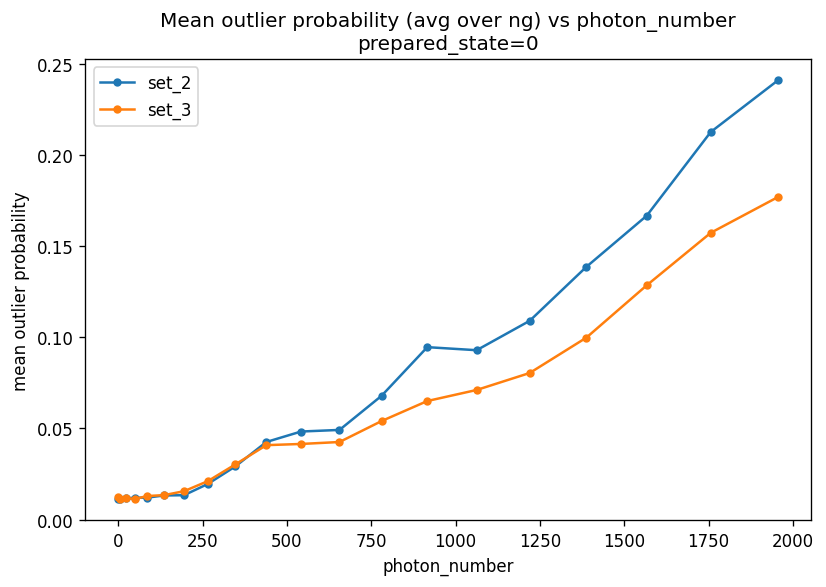

Saved mean_outlier_prob_state_1.png


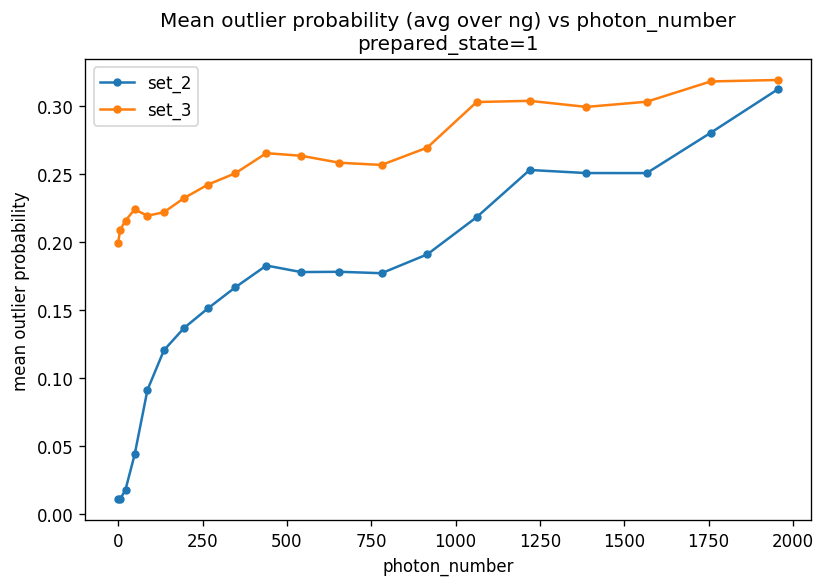

In [ ]:
# Mean outlier probability averaged along x_dim vs y_dim
# set_2 and set_3 on the same figure, one figure per prepared_state

prepared_states = result_ds.coords['prepared_state'].values

for state in prepared_states:
    fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

    for var_name, set_label in [('outlier_probability_set2', 'set_2'),
                                 ('outlier_probability_set3', 'set_3')]:
        mean_outlier_vs_amp = result_ds[var_name].sel(prepared_state=state).mean(dim=x_dim)
        mean_outlier_vs_amp.plot.line(ax=ax, marker='o', markersize=4, label=set_label)

    ax.set_xlabel(y_dim)
    ax.set_ylabel('mean outlier probability')
    ax.set_title(f'Mean outlier probability (avg over {x_dim}) vs {y_dim}\n'
                 f'prepared_state={int(state)}')
    ax.legend()
    fig.tight_layout()

    fname = f"mean_outlier_prob_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()